In [1]:
import warnings

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os

import tensorflow as tf

from tensorflow import keras
from keras import optimizers, initializers

from tensorflow.keras.callbacks import Callback
from tqdm.keras import TqdmCallback
from tqdm import tqdm

from scipy.stats import norm

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

2026-09-28 19:58:41.867042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790636321.884972   37179 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790636321.890728   37179 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1790636321.905086   37179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790636321.905112   37179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790636321.905114   37179 computation_placer.cc:177] computation placer alr

Thetaflow version: 0.0.38


I0000 00:00:1790636324.686651   37179 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4265 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


Abaixo, demonstramos as principais funcionalidades para o uso do pacote Thetaflow através de exemplos simples, cuja complexidade aumenta gradativamente.

## Distribuição $N(\mu, \sigma^2$)

Consideremos inicialmente, que os dados seguem uma distribuição normal fixa. O exemplo inferencial mais simples. Façamos a geração dos dados considerando $\mu = 5$, $\sigma^2 = 4$.

Sample mean: 5.158833325873749
Sample variance: 3.7784458597832304


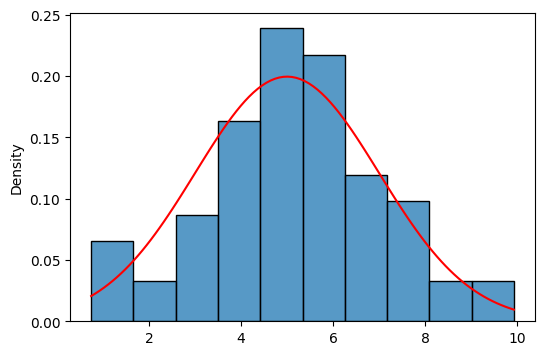

In [2]:
n = 100

mu_0 = 5
sigma2_0 = 4

np.random.seed(10)

y0 = np.random.normal(loc = mu_0, scale = np.sqrt(sigma2_0), size = n)

print("Sample mean: {}".format(np.mean(y0)))
print("Sample variance: {}".format(np.var(y0, ddof = 1)))

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))

ys = np.linspace(np.min(y0), np.max(y0), 100)
f_ys = 1 / np.sqrt(2*np.pi*sigma2_0) * np.exp( -(ys - mu_0)**2/(2*sigma2_0) )

sns.histplot(x = y0, stat = "density")
ax.plot(ys, f_ys, color = "red")
plt.show()

Para implementar este modelo com o pacote Thetaflow, notamos que temos dois parâmetros constantes, $\mu$ e $\sigma^2$. Sendo assim, declaramos os parâmetros do modelo como.

In [3]:
normal_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 1, "init": 0.0},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0}
}

O primeiro parâmetro $\mu$, que admite valores na reta, conta com função de ligação identidade, tipo "independent", indicando que se trata de uma constante global e desconhecida e forma 1, indicando ser um único valor. Por exemploficação, inicializamos o parâmetro como 1. Sempre que não informado o valor de "init", o pacote considera o valor do parâmetro irrestrito (a menos da função de ligação) como sendo igual a zero.

Por sua vez, como $\sigma^2$ é uma quantidade positiva, consideramos uma função de ligação logarítmica.

Note que definimos em "link" o inverso da função de ligação, o qual denominaremos de função de ativação. Sendo assim, o parâmetro "link" deve refletir a função que recebe o parâmetro em sua forma irrestrita (na reta $\mathbb{R}$) e retorna o parâmetro em sua forma restrita.

Agora, para estimar os parâmetros, definimos a função de verossimilhança negativa, a qual deve ser interpretada como uma função perda a ser minimizada. 

In [4]:
def normal_neg_loglikelihood_loss(model, nn_output, data):
    # Extração de variáveis
    x, y = data

    # Declaração de vínculo de variáveis Python a parâmetros do modelo
    mu = model.get_variable("mu", get_raw_value = True)
    sigma2 = model.get_variable("sigma2")

    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    
    return -loglik

A função perda sempre deve seguir este padrão, recebendo o modelo no primeiro argumento, um segundo argumento nn_output, e um terceiro argumento data. Cada argumento segue da seguinte forma:
* model: O objeto principal que suportará a estrutura do modelo estatístico e será responsável por todo o treinamento;
* nn_output: Este objeto representa a saída instantânea de uma rede neural definida na estrutura do modelo. Neste exemplo, como todos os parâmetros são do tipo "independent", o modelo simplesmente define este parâmetro como None. Entretanto, o argumento deve ser mantido na função.
* data: Este objeto se trata de uma lista com todos os dados relevantes para a análise e que entram na função de verossimilhança. Neste caso, os únicos dados relevantes para nós é o vetor de observações da distribuição $N(\mu, \sigma^2)$.

Pela primeira linha, vemos que "data" é tratado como um vetor [x, y] a ser desempacotado pelo Python. Esta variável x sempre será relacionada à entrada de uma rede neural. Como veremos adiante, para a implementação de uma regressão linear, os dados da regressão não entram nessa variável x, mas sim na variável data. Como neste caso, não são definidas componentes de redes neurais, x será automaticamente definido pelo modelo como None. Novamente, é importante que mantemos este valor na implementação da função.

Nas linhas seguintes, declaramos novas variáveis em Python, as quais representarão os parâmetros do modelo a serem inseridos na função perda. Note que o valor retornado pela função model.get_variable já está em sua versão restrita. Caso seja do interesse de trabalhar com este valor em sua versão irrestrita, pode ser adicionado o comando get_raw_value = True. Como na função acima, este comando é adicionado para o parâmetro $\mu$, como função de ligação identidade, não terá diferença nenhuma de ter ou não ter o comando. Entretanto, se adicionado para o parâmetro "sigma2", teríamos uma variável em Python log_sigma2. Note que o nome dos parâmetros "mu" e "sigma2" passados como texto para a função get_variable devem ser exatamente os nomes definidos no dicionário Python normal_parameters.

Finalmente, com os parâmetros declarados e vinculados, calculamos o valor numérico da verossimilhança negativa e retornamos o valor.

Agora que a estrutura do modelo foi definida, nos resta criar um objeto Model, da classe Thetaflow, para que a estimação dos parâmetros seja de fato realizada.

In [5]:
# Declara que o modelo deve ser interpretado pelo processador, não pela GPU
# Se o modelo deve ser considerado pela placa de vídeo (mais eficaz com imagens), substituir CPU por GPU no comando abaixo
with tf.device("/CPU:0"):
    # Define o modelo passando os parâmetros e a função de log-verossimilhança negativa
    normal_model = thf.ModelNN(normal_parameters, normal_neg_loglikelihood_loss)

    # Declara o vetor de dados como sendo uma lista contendo apenas as observações da distribuição normal
    data = [y0]

Abaixo, vejamos uma rápida documentação da função de treinamento normal_model.train_model.

Agora, não entraremos em detalhes minuciosos dessa função, focando apenas nos primeiros argumentos:
* epochs: Quantas épocas devem ser consideradas. Note que até mesmo um modelo simples como $N(\mu, \sigma^2)$ será estimado pelo método do Gradiente Descendente. Sendo assim, deve ser definido o número máximo de iterações.
* x: Este valor de x é o mesmo valor de x da função normal_neg_loglikelihood_loss. Como não temos uma estrutura de redes neurais neste caso, o definimos como None.
* data: Aqui, fornecemos os dados, na ordem como estamos extraindo na função perda normal_neg_loglikelihood_loss. Após o processamento inicial do modelo, ele irá agrupar x e esta lista data, retornando o objeto [None, y0], no caso deste modelo.
* shuffle: Determina se, no início de cada época, os dados de treinamento serão embaralhados. Neste contexto não há necessidade nenhuma de considerar batches. Entretanto, para problemas de maior dimensão, pode ser necessário para reduzir ruídos no treinamento.

In [6]:
?normal_model.train_model

Signature:
normal_model.train_model(
    epochs,
    x,
    data=None,
    shuffle=True,
    validation=False,
    n_train=None,
    n_val=None,
    x_val=None,
    data_val=None,
    val_prop=None,
    force_training_validation=False,
    optimizer_independent=<keras.src.optimizers.adam.Adam object at 0x7be56cd42260>,
    optimizer_nn=<keras.src.optimizers.adam.Adam object at 0x7be56b0b4730>,
    fine_tune_independent_lr=None,
    fine_tune_nn_lr=None,
    train_batch_size=None,
    val_batch_size=None,
    buffer_size=4096,
    gradient_accumulation_steps=None,
    early_stopping=True,
    early_stopping_patience=10,
    early_stopping_warmup=100,
    early_stopping_min_delta=0.0,
    reduce_lr=True,
    reduce_lr_warmup=0,
    reduce_lr_factor=0.5,
    reduce_lr_min_delta=0.0,
    reduce_lr_patience=5,
    reduce_lr_cooldown=0,
    reduce_lr_min_lr=1e-05,
    fine_tune=True,
    get_covariances=True,
    covariance_jitter=1e-06,
    finetune_epochs=None,
    finetune_early_stopping=

In [7]:
with tf.device("/CPU:0"):
    # Chama a função de treinamento do modelo, passando a lista de observações da distribuição normal e definindo x como None, já que não temos redes neurais aqui
    # Definimos que os dados de treinamento não devem ser separados em treinamento/validação durante o treino, já que temos um modelo puramente estatístico
    # Definimos o otimizador dos parâmetros como sendo RMSProp
    # Ao definir train_batch_size = None, o mdoelo entende que desejamos um único batch, ou seja, a cada época, o algoritmo observa todos os dados simultaneamente
    # Além disso, gradient_accumulation_steps = None é igual a 1 por padrão, sugerindo que os pesos devem ser atualizados ao final de cada batch
    # Como temos um único batch, o modelo atualiza os pesos ao final de cada época
    # Definimos o treinamento para ocorrer até que a função perda pare de melhorar por early_stopping_min_delta = 1.0e-4 durante 10 épocas seguidas
    # early_stopping_warmup define que o treinamento não deve parar antes da época 100, mesmo que já tiver convergido
    # Caso o modelo passe 5 épocas sem uma melhoria em 1.0e-4, reduz a taxa de aprendizado
    # Ele reduzirá a taxa de aprendizado do otimizador até que atinja o valor reduce_lr_min_lr = 1.0e-4. Se o modelo chega a este estágio, ele também para o treinamento
    normal_model.train_model(
        epochs = 5000, x = None, data = data, verbose = True, print_freq = 1, track_time = True,
        validation = False,
        optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
        train_batch_size = None, gradient_accumulation_steps = None,
        early_stopping = True, early_stopping_min_delta = 1.0e-4, early_stopping_patience = 10,
        early_stopping_warmup = 100,
        reduce_lr = True, reduce_lr_warmup = 0,
        reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 10,
        reduce_lr_min_lr = 1e-4
    )

Global seed set to None.
Initializing training...
Optimizing... Epoch: [ 577 / 5000 ]  | Avg. Train NLL:  1.15963745 | Best Avg. Train NLL:  1.15963745 | Speed:  691  epoch/s    | Elapsed Time:  0.83473134  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 578 / 5000 ]  | Avg. Train NLL:  1.15963745 | Best Avg. Train NLL:  1.15963745 | Speed:  691  epoch/s    | Elapsed Time:  0.836350203  s   Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 7.206 seconds.


2026-09-28 19:58:52.402102: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
sample_mean = np.mean(y0)
sample_var = np.var(y0, ddof = 1)

mu_pred = normal_model.predict("mu")[0]
sigma2_pred = normal_model.predict("sigma2")[0]

print("média amostral: {}".format(sample_mean))
print("variância amostral: {}".format(sample_var))
print("mu predito: {}".format(mu_pred))
print("sigma2 predito: {}".format(sigma2_pred))

média amostral: 5.158833325873749
variância amostral: 3.7784458597832304
mu predito: 5.1585259437561035
sigma2 predito: 3.72204852104187


Neste caso, sabemos que o máximo da verossimilhança é atingido na média e na variância amostrais. Como podemos ver, o modelo estima o máximo com uma imprecisão na segunda casa decimal. De fato, estamos utilizando um canhão para matar uma formiga aqui. Certamente, o gradiente descendente não precisa ser considerado para este problema. Ainda assim, o método é consistente e funciona. A discrepância neste caso se refere ao próprio tamanho da taxa de aprendizado, ou seja, o tamanho do passo das atualizações dos pesos do modelo. Reduzindo a taxa de aprendizado, obtemos resultados mais precisos, porém leva a um tempo de execução maior.

Podemos observar a função perda ao longo das iterações.

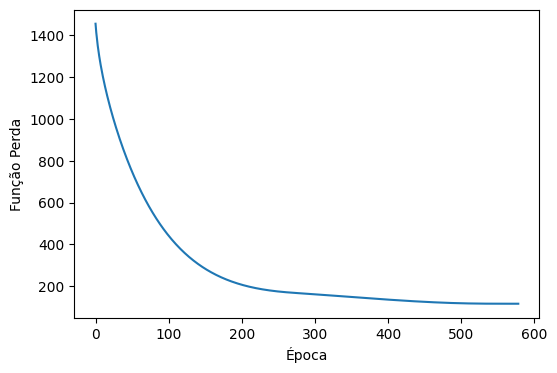

In [9]:
loss_history = normal_model.loss_history
# Último valor da perda
last_loss = np.sum(loss_history != 0)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))

ax.plot(np.arange(last_loss), loss_history[:last_loss])
ax.set_xlabel("Época")
ax.set_ylabel("Função Perda")
plt.show()

Finalmente, o modelo também é capaz de identificar a variância dos estimadores através da função summary.

In [10]:
normal_model.summary()

,index,mu,mu_se,mu_lower,mu_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,5.158526,0.192926,4.780398,5.536654,3.722049,0.525066,2.822954,4.907499


O intervalo de confiança exibido considera o interval plug-in de cada estimador. Ou seja, é calculado o intervalo de confiança do estimador irrestrito, cujos limites são mapeados para a escala original segundo uma função de ativação, justificando o fato do intervalo ser assimétrico.

## Regressão linear heteroscedástica - $Y_i \sim N(\mu_i, \sigma_i^2)$

Consideremos um exemplo mais avançado e interessante. Considere os dados gerados abaixo.

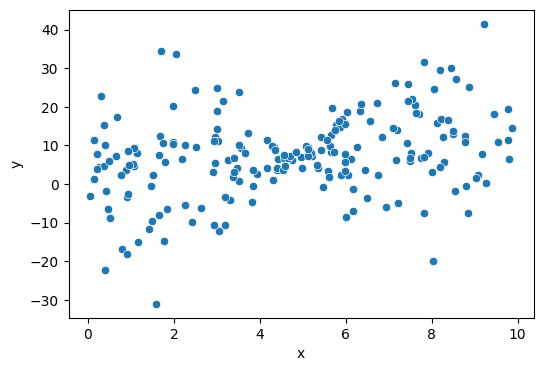

In [11]:
n = 200

np.random.seed(10)
x2 = np.random.uniform(low = 0.0, high = 10.0, size = n)

beta0 = 1
beta1 = 1.2
mu = beta0 + beta1 * x2

def true_sigma2_2(x):
    a = 100
    y = a*np.sin(x) + a + 0.5
    return y

sigma2_2 = true_sigma2_2(x2)

y2 = mu + np.random.normal(loc = 0, scale = np.sqrt(sigma2_2))

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))

sns.scatterplot(x = x2, y = y2, ax = ax)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

Temos, de fato, uma regressão linear para a média. Entretanto, a variância da distribuição normal segue uma função sinoidal não trivial. Temos o interesse em modelar a distribuição desses dados ao longo da variável $x$.

Para isso, podemos fixar que a média da distribuição varia segundo um preditor linear da variável x, mas ainda assim definindo que a variância se trata de uma função não linear. Para definirmos o novo modelo, consideremos:

\begin{align*}
    \mu &= \beta_0 + x \beta_1,\\
    \sigma^2 &= \mathcal{F}_1(x; \boldsymbol \omega),
\end{align*}
em que $\mathcal{F}_1$ representa uma rede neural arbitrária que recebe a variável $x$ e retorna a variância em cada ponto.

In [12]:
regression_parameters = {
    "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": 2, "init": 1.0},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0}
}

Note que agora, definimos os parâmetros do modelo como sendo $\boldsymbol \beta = [\beta_0, \beta_1]$, uma constante global e desconhecida de tamanho 2. Por sua vez, a variância "sigma2" agora se trata de uma variável do tipo "nn". Ou seja, o modelo trata essa quantidade como uma função não linear dos dados. Para levar isso em conta, definimos a função perda da seguinte forma.

In [13]:
def regression_loglikelihood_loss(model, nn_output, data):
    # Extrai os dados do argumento data
    # x: variável de entrada da rede neural
    # z: variável de entrada do preditor linear
    # y: variável resposta
    x, z, y = data

    # Declaração de vínculo de variáveis Python a parâmetros do modelo
    sigma2 = model.get_variable("sigma2", nn_output)
    beta = model.get_variable("beta")
    mu = beta[0] + beta[1] * z
    
    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2) - 1/(2*sigma2) * (y - mu)**2 )
    return -loglik

Note que a estrutura geral é praticamente a mesma, com algumas alterações. O argumento da função perda permanece o mesmo. Entretanto, agora o objeto data é tratado como uma lista de 3 quantidades, $x$, $z$ e $y$.
* A primeira entrada, $x$, sempre será representado como a entrada de uma rede neural. Lembremos que no exemplo anterior, x = None. Sendo assim, essa variável será contabilizada na estimação da variável "sigma2".
* A segunda entrada, $z$, representa os dados utilizados na componente linear do modelo. Neste caso em particular, coincide que os dados de entrada da rede e do preditor linear são, essencialmente, os mesmos. Sendo assim, veremos que $x$ e $z$ representam o mesmo objeto, porém sendo lidado pelo modelo de duas formas distintas.
* A terceira entrada será, finalmente, os valores da variável $y_i$ observados para cada $x_i$.

Agora, ao declarar os vínculos das variáveis python com os parâmetros definidos pelo modelo, note que parâmetros do tipo "nn" sempre deverão receber como segunda entrada o argumento nn_output. De fato, a função irá pegar o peso do modelo e fazer as devidas transformações segundo a função de ligação definida e mapear os pesos internos treináveis automaticamente. Por sua vez, tratamos a variável beta como um vetor agora. De fato, o parâmetro da média é descrito pelo modelo como $\mu_i = \beta_0 + x_i \beta_1$.

Finalmente, considerando as variáveis finais para $\mu$ e $\sigma^2$, simplesmente as utilizamos na função log-verossimilhança negativa novamente.

Note que definimos a estrutura do modelo de forma muito similar ao exemplo simples da distribuição $N(\mu, \sigma^2)$. De fato, esses exemplos também tem o propósito de demonstrar a capacidade do modelo de definir modelos cada vez mais complexos, enquanto mantém uma simplicidade nas definições. No exemplo acima, dizemos ao modelo que o parâmetro "sigma2" será modelado através de uma rede neural, mas ainda não dizemos qual a arquitetura dessa rede. Para fazermos isso, fazemos:

In [14]:
def regression_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def regression_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

No código acima, veja que definimos uma rede densa, com três camadas ocultas, tendo a primeira 16 neurônios, a segunda, 8 e a terceira, 4. Cada neurônio das camadas ocultas tem função de ativação GELU e os pesos devem ser iniciados segundo a distribuição GlorotNormal.

A função regression2_network_call especifica a ordem exata que cada camada deve ser chamada para o processamento dos dados de entrada da rede.

Finalmente, a função regression2_network_call_nolast é uma cópia de regression2_network_call, mas retorna a penúltima camada, sem os dados de saída. Fornecer essa função como entrada do modelo parece uma ação desnecessária, já que se o modelo conhece a estrutura completa, ele deveria ser capaz de separar a última camada. Por essa razão, esta função será descontinuada em versões futuras do pacote. Por ora, é necessário que a passemos ao modelo deste modo, retornando as saídas da penúltima camada.

Para finalmente definirmos o modelo e treiná-lo, passamos essas três novas funções como argumentos extras no construtor thf.ModelNN:

In [15]:
with tf.device("/CPU:0"):
    # Os dois parâmetros iniciais representam a definição dos estimadores e a função perda, como no primeiro exemplo
    # Como temos uma estrutura de redes neurais agora, passamos as três funções definidas acima como os parâmetros seguintes
    # Definimos a dimensão dos dados de entrada como a tupla (1, ). Se a rede considerasse uma tabela com 5 variáveis, teríamos a dimensão (5, ) naturalmente
    # Finalmente, definimos a semente do modelo para a definição determinística dos pesos inicializados
    regression_model = thf.ModelNN(regression_parameters, regression_loglikelihood_loss,
                                   regression_neural_network, regression_network_call, regression_network_call_nolast,
                                   input_dim = (1, ), seed = 10)

    # A variável z representa os valores de x
    z2 = x2
    # Definimos o vetor de dados como sendo a variável z e os valores da variável resposta, na ordem definida pela função regression_loglikelihood_loss
    data2 = [z2, y2]
    
    # Agora, para passar a variável x para a rede neural, é ideal que a mesma esteja padronizada
    x_scaled2 = (x2 - np.mean(x2)) / np.std(x2, ddof = 1)

    # A função pre_train_model organiza os pesos da rede de modo que os valores "init" de cada parâmetro de regression_parameters
    # De fato sejam preditos pelo modelo final.
    # Se a última camada da rede não conta com parâmetros de bias (intercepto), note que a tarefa de forçar uma rede neural a ter uma saída
    # constante não é nada trivial. Nesses casos mais complexos, essa função lida com isso da uma forma ótima.
    regression_model.pre_train_model(epochs = 500, x = x_scaled2, data = data2)

    # Finalmente, a função que realiza o treinamento do modelo é chamada de forma análoga ao exemplo anterior
    # Neste caso, consideramos que 20% dos dados de entrada serão utilizados para a validação do modelo.
    # Essa divisão é feita de forma automática pelo pacote.
    # Definimos otimizadores Adam tanto para os pesos da rede quanto para os pesos correspondentes a constantes globais desconhecidas
    regression_model.train_model(epochs = 15000, x = x_scaled2, data = data2,
                                 shuffle = True,
                                 validation = True, val_prop = 0.2,
                                 optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                 optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                 train_batch_size = None, val_batch_size = None,
                                 buffer_size = 4096, gradient_accumulation_steps = None,
                                 early_stopping = True, early_stopping_warmup = 100,
                                 reduce_lr = True, reduce_lr_warmup = 10,
                                 reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                                 reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                 verbose = 1, print_freq = 50)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 850 / 15000 ]  | Avg. Train NLL:  2.60192227 | Avg. Validation NLL:  2.63320279 | Best Avg. Validation NLL:  2.63320279 | Speed:  0.000842053734  epoch/s    | Elapsed Time:  0.715745687  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 2400 / 15000 ]  | Avg. Train NLL:  2.60023451 | Best Avg. Train NLL:  2.60023451 | Avg. Validation NLL:  2.6339891 | Speed:  0.000586660404  epoch/s    | Elapsed Time:  1.40798497  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.131 seconds.


2026-09-28 19:58:59.327149: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Veja que aqui o modelo já passa a adotar o treinamento em dois estágios definido no artigo principal (https://arxiv.org/abs/2607.14122). De fato, como temos uma rede neural envolvida, a quantificação de incerteza para funções dos parâmetros $\mu$ e $\sigma^2$ deve ser feita de forma cuidadosa, considerando a restrição do modelo a um VGLM em seu segundo estágio de treinamento.

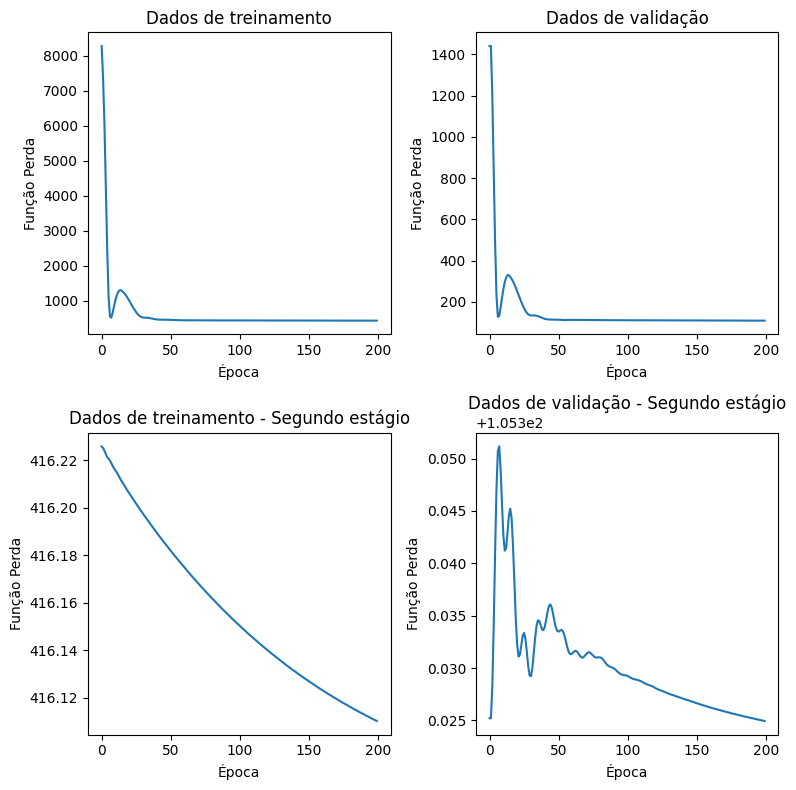

In [16]:
loss_history = regression_model.loss_history
val_loss_history = regression_model.val_loss_history
# Último valor da perda
# last_loss = np.sum(loss_history != 0)
# last_val_loss = np.sum(val_loss_history != 0)
last_loss = 200
last_val_loss = 200

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (8,8))

ax[0,0].plot(np.arange(last_loss), loss_history[:last_loss])
ax[0,0].set_xlabel("Época")
ax[0,0].set_ylabel("Função Perda")
ax[0,0].set_title("Dados de treinamento")

ax[0,1].plot(np.arange(last_val_loss), val_loss_history[:last_val_loss])
ax[0,1].set_xlabel("Época")
ax[0,1].set_ylabel("Função Perda")
ax[0,1].set_title("Dados de validação")

loss_history = regression_model.loss_history_finetune
val_loss_history = regression_model.val_loss_history_finetune
# Último valor da perda
# last_loss = np.sum(loss_history != 0)
# last_val_loss = np.sum(val_loss_history != 0)
last_loss = 200
last_val_loss = 200

ax[1,0].plot(np.arange(last_loss), loss_history[:last_loss])
ax[1,0].set_xlabel("Época")
ax[1,0].set_ylabel("Função Perda")
ax[1,0].set_title("Dados de treinamento - Segundo estágio")

ax[1,1].plot(np.arange(last_val_loss), val_loss_history[:last_val_loss])
ax[1,1].set_xlabel("Época")
ax[1,1].set_ylabel("Função Perda")
ax[1,1].set_title("Dados de validação - Segundo estágio")

fig.tight_layout()
plt.show()

Vemos um padrão na função perda muito consistente em ambos os conjuntos de treino e validação no estágio de treinamento 1. A partir do estágio 2, limitamos a estrutura do modelo ao congelar todos os pesos das camadas iniciais da rede, enquanto que atualizamos os pesos com base estritamente nos dados de treinamento (overfit consciente). Veja que de fato, isso leva ao aumento sutil da função perda para os dados de validação. Entretanto, para os dados de treinamento, forçamos com que a perda seja direcionada ao mínimo global do modelo restrito, nos possibilitando quantificar a incerteza dos estimadores.

Aogra, façamos o summary do modelo novamente.

In [17]:
regression_global_summary = regression_model.summary()
regression_global_summary

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/thetaflow/modelnn.py:2871: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,index,beta[0],beta[0]_se,beta[0]_lower,beta[0]_upper,beta[1],beta[1]_se,beta[1]_lower,beta[1]_upper
0,1,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412


Vemos que os parâmetros $\beta_0$ e $\beta_1$ foram estimador corretamente, sendo próximos de 1 e 1.2. Ainda assim, notamos que $\beta_0$ não foi significativo. De fato, estudos anteriores com o pacote sugerem que a conciliação de redes neurais com coeficientes de regressão é mais sensível ao intercepto. Uma forma de melhorar o diagnóstico do modelo neste quesito é reduzir o valor de early_stopping_min_delta, que corresponde a quanto a perda deve parar de melhorar para que a convergência seja obtida. Ao reduzir este valor, obtemos estimativas de variância mais precisas para os coeficientes de regressão.

Note que obtivemos um aviso, nos indicando que o summary está sendo feito apenas para parâmetros constantes. De fato, para que seja quantificada a incerteza do estimador de $\sigma^2$ neste caso, é preciso passar quais os valores associados a $x_i$, uma vez que a distribuição da variável resposta é dependente, como um todo, desses valores. Passando essa informação de $x$ para a função summary, temos:

In [18]:
regression_all_summary = regression_model.summary(x_scaled2)
regression_all_summary

,index,beta[0],beta[0]_se,beta[0]_lower,beta[0]_upper,beta[1],beta[1]_se,beta[1]_lower,beta[1]_upper,sigma2,sigma2_se,sigma2_lower,sigma2_upper
0,1,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,125.036674,23.078381,87.082047,179.533783
1,2,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,103.692657,35.957653,52.550350,204.606934
2,3,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,118.242493,34.065247,67.227264,207.970490
3,4,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,121.416328,22.446144,84.511551,174.436798
4,5,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,3.348002,0.997198,1.867482,6.002262
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,160.764389,41.351883,97.105400,266.156006
196,197,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,114.487183,29.244516,69.394737,188.880524
197,198,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,129.627441,25.389277,88.303452,190.290146
198,199,1.051018,1.608025,-2.100652,4.202689,1.231273,0.324056,0.596135,1.866412,64.558296,14.500717,41.568081,100.263802


Agora temos um diagnóstico individual dos parâmetros para cada observação. Enquanto as predições de $\beta$ se mantém constantes, cada observação passa a ter valores distintos de $\sigma^2$ e seu respectivo erro padrão estimado.

Uma pergunta interessante é: qual o erro padrão de $\mu$ neste caso? Embora possamos obter essa quantidade manualmente, o pacote utiliza a função variable_function_covariance exatamente para este tipo de operação.

Para isso, definimos qual a função que desejamos quantificar a incerteza. Fazemos isso de forma muito similar à forma com que definimos uma nova função perda:

In [19]:
def linear_mu(model, nn_output, data):
    x, z, y = data
    # Recupera apenas os parâmetros "beta"
    beta = model.get_variable("beta")
    mu = beta[0] + beta[1] * z
    return mu

mu_covariances = regression_model.variable_function_covariance(fun = linear_mu, data = data2, x = x2)
# Take the diagonal od the matrices
mu_variances = np.diagonal(mu_covariances, axis1 = 1, axis2 = 2).flatten()
mu_se = np.sqrt(mu_variances)
print("Erro padrão para mu (10 primeiras observações): {}".format(mu_se[:10]))

Erro padrão para mu (10 primeiras observações): [1.0103587  1.542749   0.6197263  0.9431071  0.38231865 0.91624707
 0.9957783  0.9780297  1.0831382  1.3315126 ]


Quantificando o erro padrão de $\mu$, podemos construir bandas de 95% de confiança para a variável resposta $Y_i$.

De fato, a construção exata das bandas ao rigor máximo deveria também considerar a incerteza sobre o estimador de $\sigma^2$. Entretanto, até mesmo estudos mais simples com modelos GLM adotam esse tipo de construção, dado que a variância do estimador de variância usualmente é explosiva.

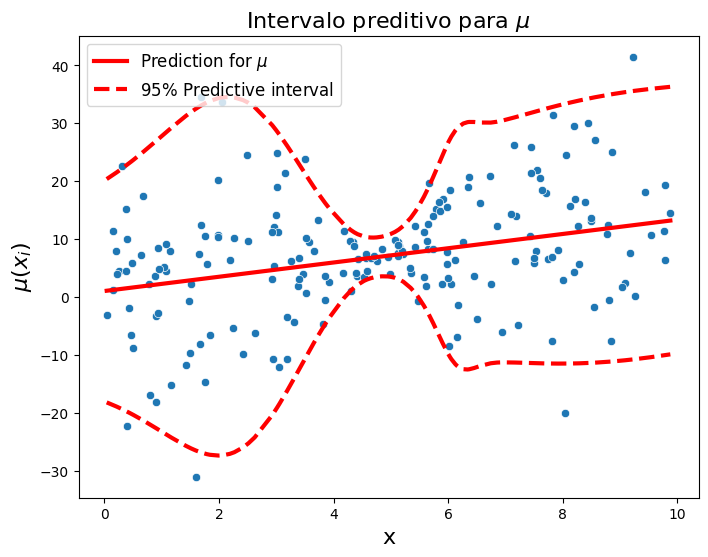

In [20]:
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)

beta_pred = regression_model.predict("beta")
# Obtém o valor de mu preditos para cada observação
mu_pred = beta_pred[0] + beta_pred[1] * x2
# Obtém o valor de sigma2 preditos para cada observação
sigma2_pred = regression_model.predict(x_scaled2)["sigma2"].numpy().flatten()

# Bandas preditivas de confiança para a variável resposta y
y_new_var2 = mu_se**2 + regression_all_summary["sigma2"]
y_new_lower2 = mu_pred - z_norm * np.sqrt(y_new_var2)
y_new_upper2 = mu_pred + z_norm * np.sqrt(y_new_var2)

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.scatterplot(x = x2, y = y2)
sns.lineplot(x = x2, y = mu_pred, color = "red", ax = ax, linewidth = 3, label = r"Prediction for $\mu$")
sns.lineplot(x = x2, y = y_new_lower2, color = "red", linestyle = "dashed", ax = ax, linewidth = 3, label = r"$95\%$ Predictive interval")
sns.lineplot(x = x2, y = y_new_upper2, color = "red", linestyle = "dashed", ax = ax, linewidth = 3)

ax.set_xlabel("x", fontsize = 16)
ax.set_ylabel(r"$\mu(x_i)$", fontsize = 16)
ax.legend(fontsize = 16)
ax.set_title(r"Intervalo preditivo para $\mu$", fontsize = 16)
ax.legend(loc = "upper left", fontsize = 12)
# ax.set_ylim(-4.5, 5.5)

plt.show()

## Modelo de sobrevivência com fração de cura - Mistura Padrão

Finalmente, consideremos um modelo de sobrevivência com fração de cura com duas covariáveis preditivas contínuas, $X_1$ e $X_2$.

Suponha que $X_1 \sim U(0, 10)$, $X_2 \sim U(-5, 5)$ e que a probabilidade de que um paciente esteja curado possa ser descrita como

\begin{equation*}
    p(X_1, X_2) = \exp\left\{ -\gamma \left[(X_1 - 5)^2 + (X_2 - 0)^2 \right]\right\}, \ \ \ \ \gamma = 0.1.
\end{equation*}

In [21]:
import plotly.graph_objects as go

# Reduzimos o n para 200 para garantir que a rotação 3D no navegador seja fluida
x1 = np.linspace(0.001, 10-0.001, 100)
x2 = np.linspace(-5+0.001, 5-0.001, 100)

x1_mesh, x2_mesh = np.meshgrid(x1, x2)
gamma = 0.1
p = np.exp(-gamma * ((x1_mesh - 5)**2 + (x2_mesh - 0)**2))

# Criando o gráfico de superfície 3D
fig = go.Figure(data = [go.Surface(z = p, x = x1_mesh, y = x2_mesh, colorscale = 'Viridis')])

# Ajustando o layout e os rótulos dos eixos
fig.update_layout(
    title='Probabilidade de imunidade ao evento de interesse',
    scene=dict(
        xaxis_title = 'X_1',
        yaxis_title = 'X_2',
        zaxis_title = 'p',
        # Ajusta a proporção da câmera para ver melhor a altura
        aspectratio = dict(x = 1, y = 1, z = 0.6) 
    ),
    width = 800,
    height = 800,
    margin = dict(l = 65, r = 50, b = 65, t = 90)
)

fig.show()

Veja que essa estrutura em particular seria um desastre para a suposição tradicional de um novo modelo de cura, atribuindo
\begin{equation*}
    p = \beta_0 + \beta_1 X_1 + \beta_2 X_2,
\end{equation*}
uma vez que a associação entre $p$ e as variáveis é, na realidade, altamente não linear. Isso pode ser facilmente contornado através do Thetaflow.

Consideremos agora que os tempos suscetíveis sejam oriundos de uma distribuição $\text{Weibull}(k = 2.0, \lambda = 4)$.

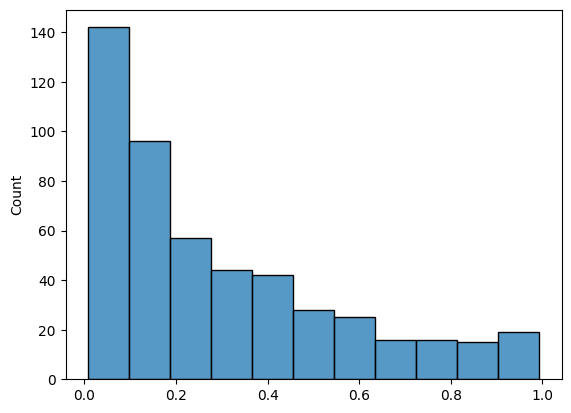

,x1,x2,y,delta,true_p,cured
0,7.713206,-4.703451,2.762091,0.0,0.052424,0
1,0.207519,-4.885715,4.843850,1.0,0.009244,0
2,6.336482,-1.681560,14.833606,0.0,0.630411,1
3,7.488039,-4.385689,1.893194,1.0,0.078673,0
4,4.985070,0.981735,8.479870,0.0,0.908098,1
5,2.247966,3.859203,10.614682,0.0,0.105746,1
6,1.980629,-0.878662,3.369400,1.0,0.371999,0
7,7.605307,-4.617278,3.022957,0.0,0.060164,0
8,1.691108,-4.191576,3.287909,1.0,0.057740,0
9,0.883398,-4.180855,3.966616,0.0,0.031982,0


In [22]:
np.random.seed(10)

n = 500

x1 = np.random.uniform(low = 0.0, high = 10.0, size = n)
x2 = np.random.uniform(low = -5.0, high = 5.0, size = n)
gamma = 0.1
p = np.exp(-gamma * ((x1 - 5)**2 + (x2 - 0)**2))

sns.histplot(p)
plt.show()

u = np.random.uniform(size = n)
cured = u <= p
susceptibles = u > p

true_k = 2.0
true_lam = 4.0

# Pacientes curados tem tempo infinito. Suscetíveis tem tempo seguindo a distribuição Weibull definida
true_t = np.ones(n) * np.inf
u_susceptibles = np.random.uniform(size = np.sum(susceptibles))
true_t[susceptibles] = true_lam * (-np.log(1 - u_susceptibles))**(1 / true_k)

# Os dados observados
C = np.random.uniform(0.0, 15.0, size = n)

y3 = true_t.copy()
delta3 = np.ones(n)

# Observações cujo tempo de censura é menor que o tempo verdadeiro são censuradas
y3[true_t > C] = C[true_t > C]
delta3[true_t > C] = 0

df = pd.DataFrame({"x1": x1, "x2": x2, "y": y3, "delta": delta3, "true_p": p, "cured": cured.astype("int")})
df.head(20)

Podemos definir o modelo da seguinte forma:

In [23]:
def sigmoid_inv(u):
    return tf.math.log(u) - tf.math.log(1-u)

mixture_cure_parameters = {
    "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0},
    "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0},
    "p": {"link": tf.math.sigmoid, "link_inv": sigmoid_inv, "par_type": "nn", "shape": 1, "init": 0.5}
}

Veja que definimos $k$ e $\lambda$ como parâmetros globais, constantes e desconhecidos, enquanto que $p$ é modelado segundo uma rede neural arbitrária. A função perda segue o mesmo padrão dos exemplos anteriores. Agora, na lista data, teremos tanto os tempos observados quanto as indicadoras de censura.

In [24]:
def mixture_cure_loglikelihood_loss(model, nn_output, data):
    # Extrai os dados do argumento data
    # x: variáveis de entrada da rede neural
    # y: tempos observados
    # delta: indicadora de censura
    x, y, delta = data

    # Declaração de vínculo de variáveis Python a parâmetros do modelo
    k = model.get_variable("k")
    lam = model.get_variable("lam")
    p = model.get_variable("p", nn_output)

    eps = 1e-7
    y_safe = y + eps
    lam_safe = lam + eps
    k_safe = k + eps

    # Termos associados à f_pop e S_pop no modelo de mistura padrão
    exp_term = (y_safe / lam_safe)**k_safe
    log_f_0 = tf.math.log(k_safe) - k_safe * tf.math.log(lam_safe) + (k_safe-1) * tf.math.log(y_safe) - exp_term
    S_0 = tf.math.exp( -exp_term )

    S_pop = p + (1 - p) * S_0
    log_S_pop = tf.math.log(tf.clip_by_value(S_pop, eps, 1.0))
    log_f_pop = tf.math.log(tf.clip_by_value(1 - p, eps, 1.0)) + log_f_0
    
    loglik = tf.reduce_sum( delta * log_f_pop + (1-delta) * log_S_pop )
    return -loglik

Adotemos a mesma arquitetura de redes neurais utilizada no segundo exemplo, com a exceção de que agora teremos duas variáveis de entrada ao invés de uma.

In [25]:
def mixture_cure_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def mixture_cure_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def mixture_cure_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

In [26]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

with tf.device("/CPU:0"):
    # Os dois parâmetros iniciais representam a definição dos estimadores e a função perda, como no primeiro exemplo
    # Note que agora input_dim = (2, )
    mixture_cure_model = thf.ModelNN(mixture_cure_parameters, mixture_cure_loglikelihood_loss,
                                     mixture_cure_neural_network, mixture_cure_network_call, mixture_cure_network_call_nolast,
                                     input_dim = (2, ), seed = 50)

    # Definimos o vetor de dados como sendo a variável z e os valores da variável resposta, na ordem definida pela função regression_loglikelihood_loss
    data3 = [y3, delta3]

    df_x = df.loc[:, ["x1", "x2"]]
    # padroniza ambas as variáveis para a rede neural
    x_scaled3 = sc.fit_transform(df_x)
    
    mixture_cure_model.train_model(epochs = 5000, x = x_scaled3, data = data3,
                                 shuffle = True,
                                 validation = True, val_prop = 0.2,
                                 optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                 optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                 train_batch_size = None, val_batch_size = None,
                                 buffer_size = 4096, gradient_accumulation_steps = None,
                                 early_stopping = True, early_stopping_warmup = 100,
                                 reduce_lr = True, reduce_lr_warmup = 10,
                                 reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                                 reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                 verbose = 1, print_freq = 1)

Global seed set to 50.
Initializing training...
Optimizing... Epoch: [ 108 / 5000 ]  | Avg. Train NLL:  1.32919502 | Avg. Validation NLL:  1.4012903 | Best Avg. Validation NLL:  1.3622272 | Speed:  0.00232810876  epoch/s    | Elapsed Time:  0.251435757  s     
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 109 / 5000 ]  | Avg. Train NLL:  1.32897139 | Avg. Validation NLL:  1.40159464 | Best Avg. Validation NLL:  1.3622272 | Speed:  0.00232723868  epoch/s    | Elapsed Time:  0.253669024  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 124 / 5000 ]  | Avg. Train NLL:  1.35359383 | Best Avg. Train NLL:  1.35359371 | Avg. Validation NLL:  1.36378098 | Speed:  0.0018706168  epoch/s    | Elapsed Time:  0.231956482  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 125 / 5000 ]  | Avg. Train NLL:  1.35359406 | Best Avg. Train NLL:  1.35359371 | Avg. Validation NLL:  1.3

Com a convergência do modelo, vejamos o diagnóstico para os parâmetros da distribuição base.

De fato, $k$ se encontra relativamente próximo de seu valor real igual a 2, enquanto que $\lambda$ também é muito próximo de $4$.

In [27]:
mixture_cure_model.summary()

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/thetaflow/modelnn.py:2871: UserWarning:

Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['k', 'lam'].



,index,k,k_se,k_lower,k_upper,lam,lam_se,lam_lower,lam_upper
0,1,1.831757,0.0974,1.650468,2.032959,3.993898,0.162435,3.687889,4.325299


Façamos o gráfico para a superfície predita para $p$ segundo a rede neural com relação às variáveis de entrada, $x_1$ e $x_2$ novamente.

In [28]:
import plotly.graph_objects as go

# Reduzimos o n para 200 para garantir que a rotação 3D no navegador seja fluida
x1 = np.linspace(0.001, 10-0.001, 100)
x2 = np.linspace(-5+0.001, 5-0.001, 100)

x1_mesh, x2_mesh = np.meshgrid(x1, x2)

mesh_shape = x1_mesh.shape
x1_mesh_flatten = x1_mesh.flatten()
x2_mesh_flatten = x2_mesh.flatten()
# Passa o grid para a estrutura de DataFrame
df_x_mesh = pd.DataFrame( np.array([x1_mesh_flatten, x2_mesh_flatten]).T )
df_x_mesh.columns = ["x1", "x2"]
df_x_mesh_scaled = sc.transform(df_x_mesh)

# gamma = 0.1
true_p = np.exp(-gamma * ((x1_mesh - 5)**2 + (x2_mesh - 0)**2))

p_pred = mixture_cure_model.predict(df_x_mesh_scaled)["p"]
p_pred = np.reshape(p_pred, mesh_shape)
x1_mesh_scaled = np.reshape(df_x_mesh_scaled[:,0], mesh_shape)
x2_mesh_scaled = np.reshape(df_x_mesh_scaled[:,1], mesh_shape)

# Criando o gráfico de superfície 3D
fig = go.Figure(data = [go.Surface(z = p_pred, x = x1_mesh, y = x2_mesh, colorscale = 'Viridis')])

# Ajustando o layout e os rótulos dos eixos
fig.update_layout(
    title='Probabilidade de imunidade ao evento de interesse',
    scene=dict(
        xaxis_title = 'X_1',
        yaxis_title = 'X_2',
        zaxis_title = 'p',
        # Ajusta a proporção da câmera para ver melhor a altura
        aspectratio = dict(x = 1, y = 1, z = 0.6) 
    ),
    width = 800,
    height = 800,
    margin = dict(l = 65, r = 50, b = 65, t = 90)
)

fig.show()

Vemos que, a superfície aprendida se assemelha muito à superfície real utilizada para a geração dos dados. Isso mosta que o modelo é capaz de estimar funções não lineares dos dados em virtualmente qualquer contexto de um modelo estatístico que tenha uma função log-verossimilhança fechada.

Outra vantagem direta do pacote é o fato que podemos construir curvas de sobrevivência preditas para quaisquer pacientes, de modo que as bandas de confiança podem ser calculadas dinamicamente com o uso da função variable_function_covariance do pacote.

Dimensão das variâncias: (3, 50)


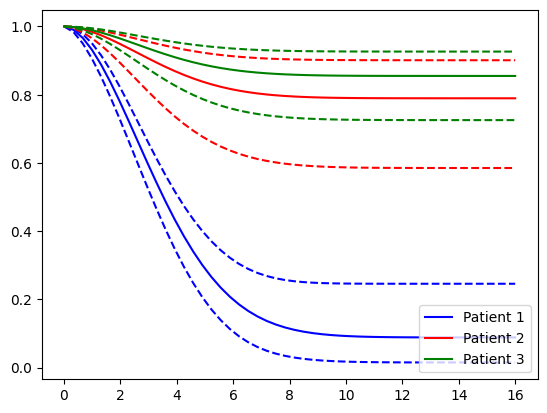

In [29]:
# Para cada tempo t em um grid e cada paciente, obtemos as bandas de confiança para o log do risco acumulado de cada paciente.
def log_cumulative_hazard(model, nn_output, data):
    X, ts, delta = data
    k = model.get_variable("k")
    lam = model.get_variable("lam")
    p = model.get_variable("p", nn_output)
    S0 = tf.math.exp( -(ts / lam)**k )
    log_H_t = tf.math.log( -tf.math.log(p + (1-p)*S0) )
    return log_H_t


# Gera o grid de tempos para a curva de sobrevivência
ts = tf.constant( np.linspace(0.01, 16, 50)[None,:], dtype = tf.float32 )

# Seleciona três pacientes da amostra
patient_indices = [0,2,4]

# Seleciona as covariáveis desses três pacientes
new_x_scaled3 = x_scaled3[patient_indices, :]

k = mixture_cure_model.predict("k")
lam = mixture_cure_model.predict("lam")
p_pred = mixture_cure_model.predict(new_x_scaled3)["p"]

# Substitui o vetor de dados agora pelo vetor vertical de tempos do grid
# ts: dimensão (1,50)
# new_deltas: dimensão (3,1)
# O objeto resultante será uma matriz (3,50)
new_deltas = tf.gather(data3[1], patient_indices)
new_data = [ ts, new_deltas ]

# Essa função considera a incerteza de todos os estimadores para calcular a incerteza final de uma função g(k, lambda, p)
# Isso é feito por meio do Método Delta, como explicado no artigo principal
log_cumulative_hazard_covariances = mixture_cure_model.variable_function_covariance(fun = log_cumulative_hazard, data = new_data, x = new_x_scaled3)
# Toma a diagonal das matrizes de covariância para cada paciente
log_cumulative_hazard_variances = np.diagonal(log_cumulative_hazard_covariances, axis1 = 1, axis2 = 2)

# Para cada paciente, temos 50 valores de variância, correspondentes à variância do risco acumulado no tempo t do grid
print("Dimensão das variâncias: {}".format(log_cumulative_hazard_variances.shape))

colors = ["blue", "red", "green", "black"]
alpha = 0.05
z_norm = norm.ppf(1-alpha/2)
log_cumulative_hazard_values = k * (np.log(ts) - np.log(lam))

pred_S0 = tf.math.exp( -(ts / lam)**k )
log_cumulative_hazard_values = tf.math.log( -tf.math.log(p_pred + (1-p_pred)*pred_S0) )

log_cumulative_hazard_lower = log_cumulative_hazard_values - z_norm * np.sqrt(log_cumulative_hazard_variances)
log_cumulative_hazard_upper = log_cumulative_hazard_values + z_norm * np.sqrt(log_cumulative_hazard_variances)

survival_values = np.exp(-np.exp( log_cumulative_hazard_values ))
survival_lower = np.exp(-np.exp( log_cumulative_hazard_lower ))
survival_upper = np.exp(-np.exp( log_cumulative_hazard_upper ))

for i, patient in enumerate(patient_indices):
    plt.plot(ts.numpy().flatten(), survival_values[i,:], color = colors[i], label = "Patient {}".format(i+1))
    plt.plot(ts.numpy().flatten(), survival_lower[i,:], linestyle = "dashed", color = colors[i])
    plt.plot(ts.numpy().flatten(), survival_upper[i,:], linestyle = "dashed", color = colors[i])
plt.legend(loc = "lower right")
plt.show()

De fato, extraindo as informações verdadeiras desses três pacientes e comparando com os valores preditos, temos:

In [30]:
new_summary = mixture_cure_model.summary(new_x_scaled3)

In [31]:
new_df_pred = df.iloc[patient_indices, :].copy().reset_index(drop = True)

new_summary.iloc[:,9:]
new_summary_p = new_summary.iloc[:,9:]
new_summary_p.columns = ["p_pred"] + list(new_summary_p.columns[1:])

new_df_pred = pd.concat( [new_df_pred, new_summary_p], axis = 1 )
new_df_pred

,x1,x2,y,delta,true_p,cured,p_pred,p_se,p_lower,p_upper
0,7.713206,-4.703451,2.762091,0.0,0.052424,0,0.088483,0.059908,0.022137,0.293909
1,6.336482,-1.681560,14.833606,0.0,0.630411,1,0.789508,0.077937,0.599356,0.903884
2,4.985070,0.981735,8.479870,0.0,0.908098,1,0.855020,0.048996,0.731027,0.927521


Ou seja, o modelo é capaz de estimar a variância de qualquer função dos dados e parâmetros estimados, o que nos possibilita construir curvas de sobrevivência individuais para cada paciente, com a sua respectiva quantificação de incerteza.